<a href="https://colab.research.google.com/github/Zdravko27/ai-lipik/blob/main/ML_model_za_klasifikaciju_kategorije.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DataFrame columns: ['File', 'Store', 'Date', 'Currency', 'Category', 'Original_Item', 'Price']
                     precision    recall  f1-score   support

             Drinks       0.47      1.00      0.64        18
               Food       1.00      0.11      0.20         9
Fruits & Vegetables       1.00      0.10      0.18        10
             Sweets       0.00      0.00      0.00         3

           accuracy                           0.50        40
          macro avg       0.62      0.30      0.26        40
       weighted avg       0.69      0.50      0.38        40



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Model saved to models/expense_classifier.pkl


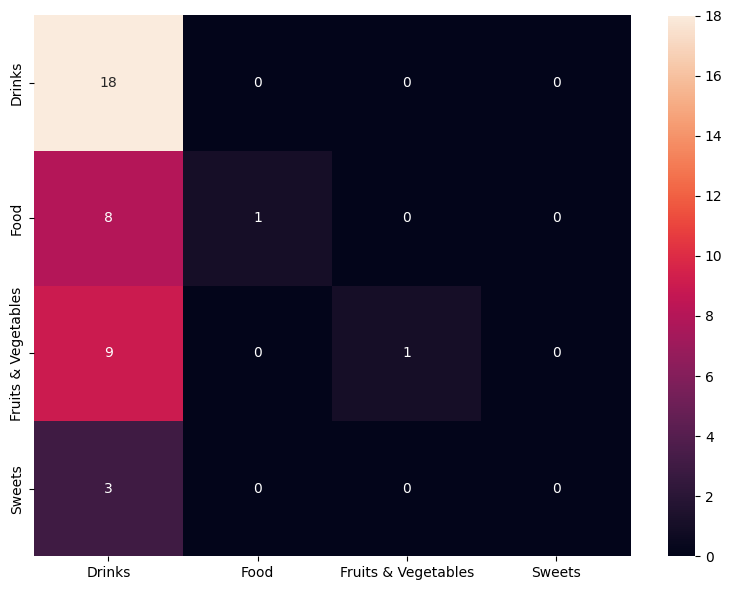

In [ ]:
# src/train_model.py
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import os # Import the os module

def main():
    df = pd.read_excel("/content/Expense_Analysis_Final_SRD.xlsx")
    print("DataFrame columns:", df.columns.tolist()) # Add this line to inspect columns
    df = df[df["Category"] != "Other"] # Changed column name from 'rule_based_category' to 'Category'

    # Filter out categories with less than 2 samples for stratified split
    category_counts = df["Category"].value_counts()
    to_keep = category_counts[category_counts >= 2].index
    df = df[df["Category"].isin(to_keep)]

    X = df["Original_Item"] # Changed column name from 'item_text' to 'Original_Item'
    y = df["Category"] # Changed column name from 'rule_based_category' to 'Category'

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
        ("clf", LogisticRegression(max_iter=1000))
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
    plt.tight_layout()
    os.makedirs('screenshots', exist_ok=True) # Create the directory if it doesn't exist
    plt.savefig("screenshots/confusion_matrix.png")

    os.makedirs('models', exist_ok=True) # Create the directory if it doesn't exist
    joblib.dump(pipe, "models/expense_classifier.pkl")
    print("Model saved to models/expense_classifier.pkl")

if __name__ == "__main__":
    main()